## Dataset Preprocessing

- simple EDA analysis of summary statistics within the full data sample
- combining relevant data sources to generate training dataset for model
- feature transformation with one-hot encoding on categorical fields
- feature engineering to create new features

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from timezonefinder import TimezoneFinder
from zoneinfo import ZoneInfo
import pytz

### load normalized data 

In [2]:
airlines = pd.read_csv('airline_dataset_normalized/airlines.csv')
airports = pd.read_csv('airline_dataset_normalized/airports.csv')
time_keys = pd.read_csv('airline_dataset_normalized/time_key.csv')
flight_status = pd.read_csv('airline_dataset_normalized/flight_status.csv', dtype='str')
flights = pd.read_csv('airline_dataset_normalized/flights.csv', dtype='str')

### prepare data for analysis

In [3]:
## merge airlines
flights = pd.merge(flights, airlines, left_on=['AIRLINE'], right_on=['IATA_CODE'], suffixes=('','_NAME'))
flights.drop(['IATA_CODE'], axis=1, inplace=True)

In [4]:
time_keys['TIME_KEY'] = time_keys['TIME_KEY'].astype(str)
flights = pd.merge(flights, time_keys)

In [5]:
print(flights.shape)
flights.head(2)

(5819079, 25)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11,21,...,04:04:00,4,04:30:00,04:08:00,-22,Alaska Airlines Inc.,2015,1,1,4
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8,12,...,07:37:00,4,07:50:00,07:41:00,-9,American Airlines Inc.,2015,1,1,4


In [6]:
## add timezone for each airport
tf = TimezoneFinder()
airports['TIMEZONE']=airports.dropna().apply(lambda x: tf.timezone_at(lat=x['LATITUDE'], lng=x['LONGITUDE']), axis=1)


## some flight records use DOT ID instead of IATA for airport
airports['DOT_ID'] = airports['DOT_ID'].astype(str)

In [7]:
## separate the flights with DOT id and flights with IATA
dot_flights = flights[(flights['ORIGIN_AIRPORT'].isin(airports['DOT_ID'])) | 
                       (flights['DESTINATION_AIRPORT'].isin(airports['DOT_ID']))]

iata_flights = flights[~((flights['ORIGIN_AIRPORT'].isin(airports['DOT_ID'])) | 
                       (flights['DESTINATION_AIRPORT'].isin(airports['DOT_ID'])))]

In [8]:
## merge with DOT to get timezone and actual IATA code 
dot_flights = pd.merge(dot_flights, airports[['DOT_ID','IATA_CODE','TIMEZONE']], 
                       left_on=['ORIGIN_AIRPORT'], right_on=['DOT_ID'], suffixes=('',''))

dot_flights = pd.merge(dot_flights, airports[['DOT_ID','IATA_CODE','TIMEZONE']], 
                       left_on=['DESTINATION_AIRPORT'], right_on=['DOT_ID'],  suffixes=('_DEPARTURE','_ARRIVAL'))

print(dot_flights.shape)
dot_flights.head(3)

(486165, 31)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,YEAR,MONTH,DAY,DAY_OF_WEEK,DOT_ID_DEPARTURE,IATA_CODE_DEPARTURE,TIMEZONE_DEPARTURE,DOT_ID_ARRIVAL,IATA_CODE_ARRIVAL,TIMEZONE_ARRIVAL
0,201510014,AA,1230,N3DBAA,14747,11298,00:05:00,00:15:00,10,15,...,2015,10,1,4,14747,SEA,America/Los_Angeles,11298,DFW,America/Chicago
1,201510014,DL,1805,N696DL,14771,13487,00:05:00,00:16:00,11,14,...,2015,10,1,4,14771,SFO,America/Los_Angeles,13487,MSP,America/Chicago
2,201510014,NK,612,N602NK,12889,13487,00:05:00,NaN,-5,15,...,2015,10,1,4,12889,LAS,America/Los_Angeles,13487,MSP,America/Chicago


In [9]:
## replace ORIGIN/DESTINATION AIRPORT
dot_flights['ORIGIN_AIRPORT'] = dot_flights['IATA_CODE_DEPARTURE']
dot_flights['DESTINATION_AIRPORT'] = dot_flights['IATA_CODE_ARRIVAL']

dot_flights.drop(['IATA_CODE_DEPARTURE','IATA_CODE_ARRIVAL','DOT_ID_DEPARTURE','DOT_ID_ARRIVAL'], axis=1,inplace=True)

In [10]:
dot_flights.head(3)

,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL
0,201510014,AA,1230,N3DBAA,SEA,DFW,00:05:00,00:15:00,10,15,...,06:02:00,05:43:00,-19,American Airlines Inc.,2015,10,1,4,America/Los_Angeles,America/Chicago
1,201510014,DL,1805,N696DL,SFO,MSP,00:05:00,00:16:00,11,14,...,05:38:00,05:28:00,-10,Delta Air Lines Inc.,2015,10,1,4,America/Los_Angeles,America/Chicago
2,201510014,NK,612,N602NK,LAS,MSP,00:05:00,NaN,-5,15,...,05:02:00,04:48:00,-14,Spirit Air Lines,2015,10,1,4,America/Los_Angeles,America/Chicago


In [11]:
## merge with IATA to get timezone
iata_flights = pd.merge(iata_flights, airports[['IATA_CODE','TIMEZONE']], 
                       left_on=['ORIGIN_AIRPORT'], right_on=['IATA_CODE'], suffixes=('',''))

iata_flights = pd.merge(iata_flights, airports[['IATA_CODE','TIMEZONE']], 
                       left_on=['DESTINATION_AIRPORT'], right_on=['IATA_CODE'],  suffixes=('_DEPARTURE','_ARRIVAL'))


iata_flights.drop(['IATA_CODE_DEPARTURE','IATA_CODE_ARRIVAL'], axis=1,inplace=True)

print(iata_flights.shape)
iata_flights.head(3)

(5332914, 27)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11,21,...,04:30:00,04:08:00,-22,Alaska Airlines Inc.,2015,1,1,4,America/Anchorage,America/Los_Angeles
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8,12,...,07:50:00,07:41:00,-9,American Airlines Inc.,2015,1,1,4,America/Los_Angeles,America/New_York
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2,16,...,08:06:00,08:11:00,5,US Airways Inc.,2015,1,1,4,America/Los_Angeles,America/New_York


In [12]:
## combine flights back into 1 dataframe

flights_all = pd.concat([iata_flights, dot_flights], ignore_index=True).sort_values(['MONTH','DAY'])
print(flights_all.shape)
flights_all.head(3)

(5819079, 27)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11,21,...,04:30:00,04:08:00,-22,Alaska Airlines Inc.,2015,1,1,4,America/Anchorage,America/Los_Angeles
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8,12,...,07:50:00,07:41:00,-9,American Airlines Inc.,2015,1,1,4,America/Los_Angeles,America/New_York
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2,16,...,08:06:00,08:11:00,5,US Airways Inc.,2015,1,1,4,America/Los_Angeles,America/New_York


In [13]:
int_cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','TAXI_OUT',
            'SCHEDULED_TIME','ELAPSED_TIME','AIR_TIME','DISTANCE',
            'TAXI_IN','ARRIVAL_DELAY']


for ic in int_cols:
    flights_all[ic] = flights_all[ic].astype(float)

### initial EDA

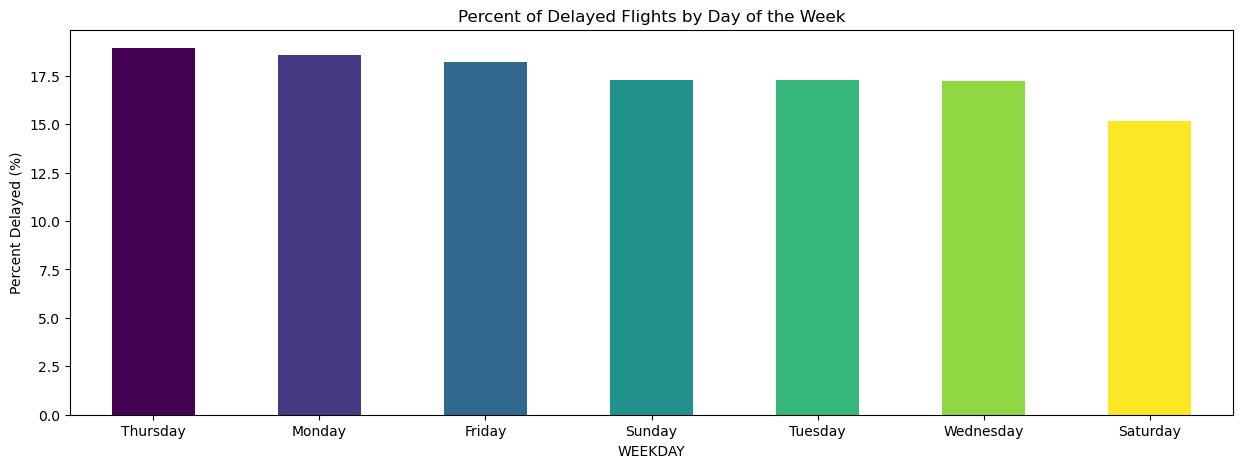

In [14]:
plot_df = (
    flights_all[['YEAR','MONTH','DAY','DAY_OF_WEEK','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
             'AIRLINE_NAME','ARRIVAL_DELAY']].copy()
)
plot_df['DELAYED']=0
plot_df.loc[plot_df['ARRIVAL_DELAY'] > 15, 'DELAYED'] = 1

us_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday","Sunday"]
plot_df['WEEKDAY'] = plot_df['DAY_OF_WEEK'].apply(lambda x: us_days[x-1])

plot_df = plot_df.groupby(['WEEKDAY']).agg({'DELAYED':['sum','count']})
plot_df.columns = ['_'.join(col) for col in plot_df.columns]
plot_df['pct_delayed'] = (plot_df['DELAYED_sum'] / plot_df['DELAYED_count']) * 100
plot_df.sort_values('pct_delayed', ascending=False, inplace=True)


colors = plt.cm.viridis(np.linspace(0, 1, len(plot_df)))

fig, ax = plt.subplots(figsize=(15, 5))
plot_df['pct_delayed'].plot(kind='bar', color=colors)

plt.title('Percent of Delayed Flights by Day of the Week')
plt.ylabel('Percent Delayed (%)')
plt.xticks(rotation=0)
plt.show()


The percent of delayed flights is fairly consistent for each day of the week. Thursday and Monday have the highest percent. Saturday is noticeably lower for percent of delayed flights.

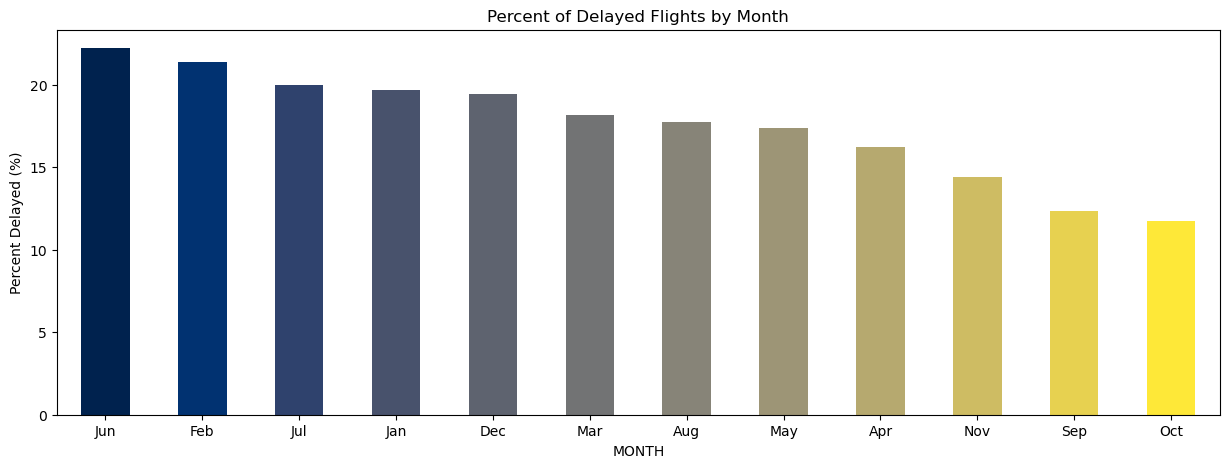

In [15]:
plot_df = (
    flights_all[['MONTH','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
             'AIRLINE_NAME','ARRIVAL_DELAY']].copy()
)
plot_df['DELAYED']=0
plot_df.loc[plot_df['ARRIVAL_DELAY'] > 15, 'DELAYED'] = 1

us_days = ["Jan", "Feb", "Mar", "Apr", "May", "Jun","Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plot_df['MONTH'] = plot_df['MONTH'].apply(lambda x: us_days[x-1])

plot_df = plot_df.groupby(['MONTH']).agg({'DELAYED':['sum','count']})
plot_df.columns = ['_'.join(col) for col in plot_df.columns]
plot_df['pct_delayed'] = (plot_df['DELAYED_sum'] / plot_df['DELAYED_count']) * 100
plot_df.sort_values('pct_delayed', ascending=False, inplace=True)


colors = plt.cm.cividis(np.linspace(0, 1, len(plot_df)))

fig, ax = plt.subplots(figsize=(15, 5))
plot_df['pct_delayed'].plot(kind='bar', color=colors)

plt.title('Percent of Delayed Flights by Month')
plt.ylabel('Percent Delayed (%)')
plt.xticks(rotation=0)
plt.show()

Months with most delays tend to be split between Summer Month (Jun/Jul) and Winter/Holiday (Dec,Jan,Feb). Travel is likely more hectic during these months due to weather and more people traveling for the holidays and/or vacation. September and October have the lowest percent of delayed flights. This supports the assumption that there may be seasonality effects on travel and delays.

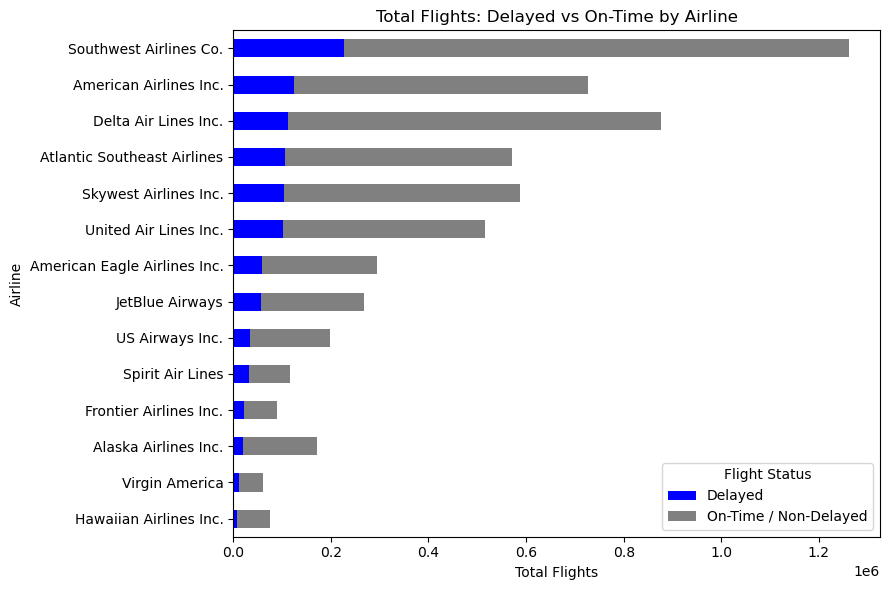

In [16]:
plot_df = (
    flights_all[['YEAR','MONTH','DAY','DAY_OF_WEEK','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
             'AIRLINE_NAME','ARRIVAL_DELAY']].copy()
)
plot_df['DELAYED']=0
plot_df.loc[plot_df['ARRIVAL_DELAY'] > 15, 'DELAYED'] = 1

plot_df = plot_df.groupby(['AIRLINE_NAME']).agg({'DELAYED':['sum','count']})
plot_df.columns = ['_'.join(col) for col in plot_df.columns]
plot_df['NON_DELAYED'] = plot_df['DELAYED_count'] - plot_df['DELAYED_sum']

chart_data = plot_df[['DELAYED_sum', 'NON_DELAYED']].rename(columns={
    'DELAYED_sum': 'Delayed',
    'NON_DELAYED': 'On-Time / Non-Delayed'
}).sort_values('Delayed')


ax = chart_data.plot(
    kind='barh', 
    stacked=True, 
    figsize=(9, 6), 
    color=['blue', 'gray']
)

plt.title('Total Flights: Delayed vs On-Time by Airline')
plt.ylabel('Airline')
plt.xlabel('Total Flights')
# plt.xticks(rotation=45)
plt.legend(title='Flight Status')
plt.tight_layout()
plt.show()

Another way to analyze the number of delayed flights is by Airline. With a stacked bar chart, we can observe the breakdown of delayed flights vs on-time flights for each Airline. This also lets us see how skewed the distribution of flights are towards certain Airlines. Southwest Airlines has the biggest footprint in the dataset, and also the most delayed flights. Delta has similar number of delayed flights as American Airlines, but also operates more flights, so Delta is performing slight better than American Airlines. From this plot, we can also see the most flights are not delayed, so classification of delayed flights would need to target the minority class in the dataset.

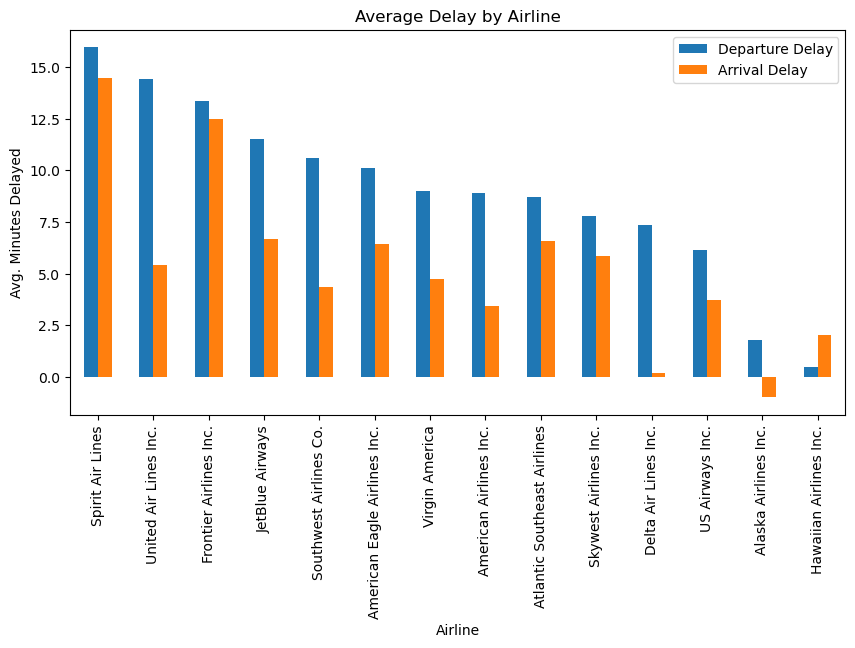

In [17]:
plot_df = flights_all.groupby('AIRLINE_NAME').agg(
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    avg_arr_delay=('ARRIVAL_DELAY', 'mean'),
).sort_values('avg_dep_delay', ascending=False)

ax = plot_df[['avg_dep_delay', 'avg_arr_delay']].plot(
    kind='bar', 
    title='Average Delay by Airline',
    figsize=(10, 5), 
)


plt.ylabel('Avg. Minutes Delayed')
plt.xlabel('Airline')
plt.legend(['Departure Delay', 'Arrival Delay'])
plt.show()

Both Spirit Airlines and Frontier Airlines have long average departure delays and arrival delays. While United Air Lines has long average departure delay, but the average arrival delays are lower indicating that during travel they make up the time or estimate flight duration in a way that accounts for some departure delay so that arrival time is aligned.

Since we know that majority of flights are not delayed, this also indicates that some of these airlines like Spirit Airlines, although infrequenct, may be experiencing severe delays.

### filter for modeling

In [18]:
## use first month of data
flights_sub = flights_all[flights_all['TIME_KEY'] <= '201501316'].copy()
# flights_sub = flights.copy()

print(flights_sub.shape)
flights_sub.head(3)

(469968, 27)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,04:30:00,04:08:00,-22.0,Alaska Airlines Inc.,2015,1,1,4,America/Anchorage,America/Los_Angeles
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,07:50:00,07:41:00,-9.0,American Airlines Inc.,2015,1,1,4,America/Los_Angeles,America/New_York
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,08:06:00,08:11:00,5.0,US Airways Inc.,2015,1,1,4,America/Los_Angeles,America/New_York


### merge flights and flight status

In [19]:
flights_m = pd.merge(flights_sub, flight_status, 
                     on = ['TIME_KEY','AIRLINE','FLIGHT_NUMBER','TAIL_NUMBER',
                           'ORIGIN_AIRPORT','DESTINATION_AIRPORT'], 
                     how ='left')

## confirm same
print(flights_sub.shape)
print(flights_m.shape)
flights_m.head(3)

(469968, 27)
(469968, 30)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,AIRLINE_NAME,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL,DIVERTED,CANCELLED,CANCELLATION_REASON
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,Alaska Airlines Inc.,2015,1,1,4,America/Anchorage,America/Los_Angeles,0,0,NaN
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,American Airlines Inc.,2015,1,1,4,America/Los_Angeles,America/New_York,0,0,NaN
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,US Airways Inc.,2015,1,1,4,America/Los_Angeles,America/New_York,0,0,NaN


In [20]:
## drop cancelled flight
flights_m = flights_m[flights_m['CANCELLED'] == '0'].copy()
flights_m = flights_m[flights_m['DIVERTED'] == '0'].copy()

flights_m.drop(['CANCELLED','DIVERTED'], axis=1, inplace=True)
print(flights_m.shape)

(457013, 28)


### clean flight times

In [21]:
### clean flight times
flight_time_cols = ['SCHEDULED_DEPARTURE','DEPARTURE_TIME','WHEELS_OFF','WHEELS_ON','SCHEDULED_ARRIVAL','ARRIVAL_TIME']

for ftc in flight_time_cols:
    flights_m[ftc] = pd.to_datetime(flights_m[ftc], format="%H:%M:%S", errors='coerce').dt.time

In [22]:
### determing arrival time and departure time if null based on delay
flights_m['DEPARTURE_TIME'] = pd.to_datetime(flights_m['SCHEDULED_DEPARTURE'],format="%H:%M:%S") + pd.to_timedelta(
    flights_m['DEPARTURE_DELAY'].fillna(0), unit='m'
)
flights_m['DEPARTURE_TIME'] = flights_m['DEPARTURE_TIME'].dt.time


flights_m['ARRIVAL_TIME'] = pd.to_datetime(flights_m['SCHEDULED_ARRIVAL'],format="%H:%M:%S") + pd.to_timedelta(
    flights_m['ARRIVAL_DELAY'].fillna(0), unit='m'
)
flights_m['ARRIVAL_TIME'] = flights_m['ARRIVAL_TIME'].dt.time

### create time buckets

In [23]:
## label red eye flights (from 9pm to 9am )

dep_time_mask = pd.to_datetime(flights_m['DEPARTURE_TIME'], format="%H:%M:%S").dt.hour
arr_time_mask = pd.to_datetime(flights_m['ARRIVAL_TIME'], format="%H:%M:%S").dt.hour

flights_m['DEPARTURE_HOUR'] = dep_time_mask
flights_m['ARRIVAL_HOUR'] = arr_time_mask

## depart between 9pm - 1am
dep_cond = (dep_time_mask >= 21) | (dep_time_mask <= 1)

## arrive between 5am - 7am
arr_cond = (arr_time_mask >= 5) & (arr_time_mask <= 8)

flights_m['IS_RED_EYE'] = 0
flights_m.loc[(dep_cond) & (arr_cond), 'IS_RED_EYE'] = 1

In [24]:
print(flights_m.shape)
flights_m.head(3)

(457013, 31)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMEZONE_DEPARTURE,TIMEZONE_ARRIVAL,CANCELLATION_REASON,DEPARTURE_HOUR,ARRIVAL_HOUR,IS_RED_EYE
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,2015,1,1,4,America/Anchorage,America/Los_Angeles,NaN,23,4,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,2015,1,1,4,America/Los_Angeles,America/New_York,NaN,0,7,1
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,2015,1,1,4,America/Los_Angeles,America/New_York,NaN,0,8,1


In [25]:
def convert_hour_to_standard(hour_float):
    # Convert float to integer hour
    hour = int(hour_float)
    
    # Determine AM or PM
    period = "AM" if hour < 12 else "PM"
    
    # Convert hour to 12-hour format
    standard_hour = hour % 12
    if standard_hour == 0:
        standard_hour = 12
        
    return f"{standard_hour}{period}"

In [26]:
depart_time_dummy_df = pd.get_dummies(
    dep_time_mask.dropna().map(convert_hour_to_standard),
    prefix='DEPART', 
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)

arrival_time_dummy_df = pd.get_dummies(
    arr_time_mask.dropna().map(convert_hour_to_standard),
    prefix='ARRIVE', 
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)

flights_m = pd.concat([flights_m, depart_time_dummy_df], axis=1)
flights_m = pd.concat([flights_m, arrival_time_dummy_df], axis=1)

print(flights_m.shape)
flights_m.head(3)

(457013, 77)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ARRIVE_5AM,ARRIVE_5PM,ARRIVE_6AM,ARRIVE_6PM,ARRIVE_7AM,ARRIVE_7PM,ARRIVE_8AM,ARRIVE_8PM,ARRIVE_9AM,ARRIVE_9PM
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0,0,0,0,1,0,0,0,0,0
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0,0,0,0,0,0,1,0,0,0


### get total number of flights each hour (arriving/departing)

In [27]:
num_flights = flights_m.groupby(['TIME_KEY','DEPARTURE_HOUR'])[['FLIGHT_NUMBER']].count()
num_flights.columns=['DEPARTURE_FLIGHT_COUNT']
num_flights.reset_index(inplace=True)
print(num_flights.shape)
num_flights.head()

(733, 3)


,TIME_KEY,DEPARTURE_HOUR,DEPARTURE_FLIGHT_COUNT
0,201501014,0,62
1,201501014,1,27
2,201501014,2,6
3,201501014,3,2
4,201501014,4,7


In [28]:
num_flights2 = flights_m.groupby(['TIME_KEY','ARRIVAL_HOUR'])[['FLIGHT_NUMBER']].count()
num_flights2.columns=['ARRIVAL_FLIGHT_COUNT']
num_flights2.reset_index(inplace=True)
print(num_flights2.shape)
num_flights2.head()

(743, 3)


,TIME_KEY,ARRIVAL_HOUR,ARRIVAL_FLIGHT_COUNT
0,201501014,0,273
1,201501014,1,80
2,201501014,2,21
3,201501014,3,10
4,201501014,4,41


In [29]:
### combine to get total flight count occurring that hour

r1 = pd.merge(num_flights, num_flights2, 
         left_on=['TIME_KEY','DEPARTURE_HOUR'], 
         right_on=['TIME_KEY','ARRIVAL_HOUR'],how='outer')

r1['TOTAL_FLIGHTS'] = r1[['DEPARTURE_FLIGHT_COUNT','ARRIVAL_FLIGHT_COUNT']].sum(axis=1).astype(int)

r1.head(3)

,TIME_KEY,DEPARTURE_HOUR,DEPARTURE_FLIGHT_COUNT,ARRIVAL_HOUR,ARRIVAL_FLIGHT_COUNT,TOTAL_FLIGHTS
0,201501014,0.0,62.0,0,273,335
1,201501014,1.0,27.0,1,80,107
2,201501014,2.0,6.0,2,21,27


In [30]:
flights_m = pd.merge(flights_m, num_flights)
flights_m = pd.merge(flights_m, num_flights2)

## merge in total flight count for the arrival hour
flights_m = pd.merge(flights_m, r1[['TIME_KEY','ARRIVAL_HOUR','TOTAL_FLIGHTS']])
flights_m.rename(columns={'TOTAL_FLIGHTS':'TOTAL_FLIGHTS_ARRIVAL_HOUR'}, inplace=True)

## merge in total flight count for the departure hour
flights_m = pd.merge(flights_m, r1[['TIME_KEY','DEPARTURE_HOUR','TOTAL_FLIGHTS']])
flights_m.rename(columns={'TOTAL_FLIGHTS':'TOTAL_FLIGHTS_DEPARTURE_HOUR'}, inplace=True)

print(flights_m.shape)
flights_m.head(4)

(457013, 81)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ARRIVE_7AM,ARRIVE_7PM,ARRIVE_8AM,ARRIVE_8PM,ARRIVE_9AM,ARRIVE_9PM,DEPARTURE_FLIGHT_COUNT,ARRIVAL_FLIGHT_COUNT,TOTAL_FLIGHTS_ARRIVAL_HOUR,TOTAL_FLIGHTS_DEPARTURE_HOUR
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,0,0,132,41,48,707
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,1,0,0,0,0,0,62,235,899,335
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0,0,1,0,0,0,62,428,1201,335
3,201501014,AA,258,N3HYAA,LAX,MIA,00:20:00,00:15:00,-5.0,15.0,...,1,0,0,0,0,0,62,235,899,335


In [31]:
## get flights per airline
num_airline_flights = flights_m.groupby(['TIME_KEY','AIRLINE','DEPARTURE_HOUR'])[['FLIGHT_NUMBER']].count()
num_airline_flights.columns=['DEPARTURE_AIRLINE_FLIGHT_COUNT']
num_airline_flights.reset_index(inplace=True)
num_airline_flights.head()


,TIME_KEY,AIRLINE,DEPARTURE_HOUR,DEPARTURE_AIRLINE_FLIGHT_COUNT
0,201501014,AA,0,13
1,201501014,AA,1,5
2,201501014,AA,5,20
3,201501014,AA,6,76
4,201501014,AA,7,83


In [32]:
num_airline_flights2 = flights_m.groupby(['TIME_KEY','AIRLINE','ARRIVAL_HOUR'])[['FLIGHT_NUMBER']].count()
num_airline_flights2.columns=['ARRIVAL_AIRLINE_FLIGHT_COUNT']
num_airline_flights2.reset_index(inplace=True)
num_airline_flights2.head()


,TIME_KEY,AIRLINE,ARRIVAL_HOUR,ARRIVAL_AIRLINE_FLIGHT_COUNT
0,201501014,AA,0,43
1,201501014,AA,1,17
2,201501014,AA,2,1
3,201501014,AA,3,2
4,201501014,AA,5,12


In [33]:
flights_m = pd.merge(flights_m, num_airline_flights)
flights_m = pd.merge(flights_m, num_airline_flights2)


print(flights_m.shape )
flights_m.head(4)

(457013, 83)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ARRIVE_8AM,ARRIVE_8PM,ARRIVE_9AM,ARRIVE_9PM,DEPARTURE_FLIGHT_COUNT,ARRIVAL_FLIGHT_COUNT,TOTAL_FLIGHTS_ARRIVAL_HOUR,TOTAL_FLIGHTS_DEPARTURE_HOUR,DEPARTURE_AIRLINE_FLIGHT_COUNT,ARRIVAL_AIRLINE_FLIGHT_COUNT
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,132,41,48,707,12,5
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0,0,0,0,62,235,899,335,13,19
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,1,0,0,0,62,428,1201,335,7,36
3,201501014,AA,258,N3HYAA,LAX,MIA,00:20:00,00:15:00,-5.0,15.0,...,0,0,0,0,62,235,899,335,13,19


In [34]:
## airline arriving/departing flights out of arriving/derparturing that hr
flights_m['AIRLINE_ARRIVAL_PROP'] = flights_m['ARRIVAL_AIRLINE_FLIGHT_COUNT'] / flights_m['ARRIVAL_FLIGHT_COUNT']
flights_m['AIRLINE_DEPARTURE_PROP'] = flights_m['DEPARTURE_AIRLINE_FLIGHT_COUNT'] / flights_m['DEPARTURE_FLIGHT_COUNT']

## flight prop out of total flights out of arriving + departing that hr
flights_m['ARRIVAL_PROP'] = flights_m['ARRIVAL_FLIGHT_COUNT'] / flights_m['TOTAL_FLIGHTS_ARRIVAL_HOUR']
flights_m['DEPARTURE_PROP'] = flights_m['DEPARTURE_FLIGHT_COUNT'] / flights_m['TOTAL_FLIGHTS_DEPARTURE_HOUR']

In [35]:
flights_m.head(3)

,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,DEPARTURE_FLIGHT_COUNT,ARRIVAL_FLIGHT_COUNT,TOTAL_FLIGHTS_ARRIVAL_HOUR,TOTAL_FLIGHTS_DEPARTURE_HOUR,DEPARTURE_AIRLINE_FLIGHT_COUNT,ARRIVAL_AIRLINE_FLIGHT_COUNT,AIRLINE_ARRIVAL_PROP,AIRLINE_DEPARTURE_PROP,ARRIVAL_PROP,DEPARTURE_PROP
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,132,41,48,707,12,5,0.121951,0.090909,0.854167,0.186704
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,62,235,899,335,13,19,0.080851,0.209677,0.261402,0.185075
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,62,428,1201,335,7,36,0.084112,0.112903,0.356370,0.185075


In [36]:
## drop redundant metrics
flights_m.drop(['DEPARTURE_AIRLINE_FLIGHT_COUNT','ARRIVAL_AIRLINE_FLIGHT_COUNT'], axis=1, inplace=True)

### create flag for day of the week

In [37]:
flights_m['DAY_OF_WEEK'] = flights_m['TIME_KEY'].apply(lambda x: x[-1:])

In [38]:
# Map numbers to names (1 = Monday)
day_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday',
}

# Apply to your DataFrame column
flights_m['DAY_OF_WEEK_NAME'] = flights_m['DAY_OF_WEEK'].astype(int).map(day_map)

In [39]:
weekday_dummy_df = pd.get_dummies(
    flights_m[['DAY_OF_WEEK_NAME']],
    prefix=['is'],
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)

flights_m = pd.concat([flights_m, weekday_dummy_df], axis=1)

print(flights_m.shape)
flights_m.head(3)

(457013, 92)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,AIRLINE_DEPARTURE_PROP,ARRIVAL_PROP,DEPARTURE_PROP,DAY_OF_WEEK_NAME,is_Monday,is_Saturday,is_Sunday,is_Thursday,is_Tuesday,is_Wednesday
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0.090909,0.854167,0.186704,Thursday,0,0,0,1,0,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0.209677,0.261402,0.185075,Thursday,0,0,0,1,0,0
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0.112903,0.356370,0.185075,Thursday,0,0,0,1,0,0


In [40]:
flights_m.drop(['DAY_OF_WEEK','DAY_OF_WEEK_NAME'], axis=1, inplace=True)

### create flag for airline

In [41]:
airline_dummy_df = pd.get_dummies(
    flights_m[['AIRLINE']], 
    prefix=['AIRLINE'], 
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)

flights_m = pd.concat([flights_m, airline_dummy_df], axis=1)

print(flights_m.shape)
flights_m.head(3)

(457013, 103)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,AIRLINE_EV,AIRLINE_F9,AIRLINE_HA,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0,0,0,0,0,0,0,0,0,0
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0,0,0,0,0,0,0,1,0,0


### create flags for origin airport

In [42]:
airport_dummy_df = pd.get_dummies(
    flights_m[['ORIGIN_AIRPORT']], 
    prefix=['DEPART'], 
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)


flights_m = pd.concat([flights_m, airport_dummy_df], axis=1)
print(flights_m.shape)
flights_m.head(3)

(457013, 414)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,DEPART_TYR,DEPART_TYS,DEPART_UST,DEPART_VEL,DEPART_VLD,DEPART_VPS,DEPART_WRG,DEPART_XNA,DEPART_YAK,DEPART_YUM
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0,0,0,0,0,0,0,0,0,0
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
airport_dummy_df = pd.get_dummies(
    flights_m[['DESTINATION_AIRPORT']], 
    prefix=['ARRIVE'], 
    drop_first=True, ## drop 1 column to avoid dummy variable trap
    dtype=int
)


flights_m = pd.concat([flights_m, airport_dummy_df], axis=1)
print(flights_m.shape)
flights_m.head(3)

(457013, 725)


,TIME_KEY,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ARRIVE_TYR,ARRIVE_TYS,ARRIVE_UST,ARRIVE_VEL,ARRIVE_VLD,ARRIVE_VPS,ARRIVE_WRG,ARRIVE_XNA,ARRIVE_YAK,ARRIVE_YUM
0,201501014,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,201501014,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8.0,12.0,...,0,0,0,0,0,0,0,0,0,0
2,201501014,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2.0,16.0,...,0,0,0,0,0,0,0,0,0,0


### label flight delay

In [44]:
## when late, most flights are less than 15 minutes late
## presence of extreme outliers
pd.DataFrame(flights_m[flights_m['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY'].describe(percentiles=[.1,.25,.5,.75,.9,.95])).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
ARRIVAL_DELAY,183110.0,32.755759,50.504409,1.0,3.0,6.0,16.0,39.0,82.0,121.0,1971.0


In [45]:
## when early, most flights arrive at least 10 minutes early
pd.DataFrame(flights_m[flights_m['ARRIVAL_DELAY'] < 0]['ARRIVAL_DELAY'].describe(percentiles=[.1,.25,.5,.75,.9,.95])).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
ARRIVAL_DELAY,263777.0,-12.666093,8.606957,-82.0,-24.0,-17.0,-11.0,-6.0,-3.0,-2.0,-1.0


In [46]:
## code late arriving flights, more than 15 mins

flights_m['LATE_ARRIVAL'] = 0
flights_m.loc[flights_m['ARRIVAL_DELAY'] >= 15, 'LATE_ARRIVAL'] = 1

flights_m['LATE_ARRIVAL'].value_counts()

LATE_ARRIVAL
0    361062
1     95951
Name: count, dtype: int64

<Axes: >

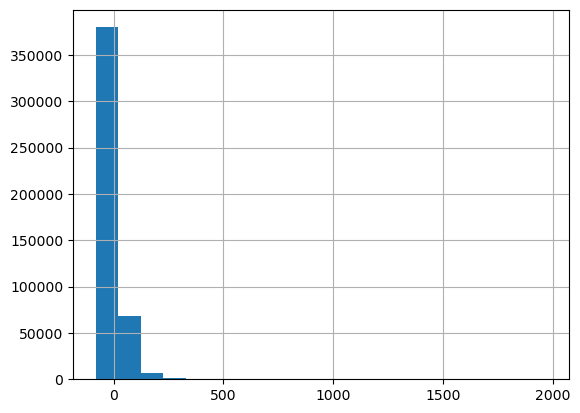

In [47]:
## presence of extreme outliers
flights_m['ARRIVAL_DELAY'].hist(bins=20)

In [48]:
## remove outliers
arrival_max = flights_m['ARRIVAL_DELAY'].quantile(.99)
arrival_min = flights_m['ARRIVAL_DELAY'].quantile(.01)


flights_m = flights_m[flights_m['ARRIVAL_DELAY'] < arrival_max]
flights_m = flights_m[flights_m['ARRIVAL_DELAY'] > arrival_min]

<Axes: >

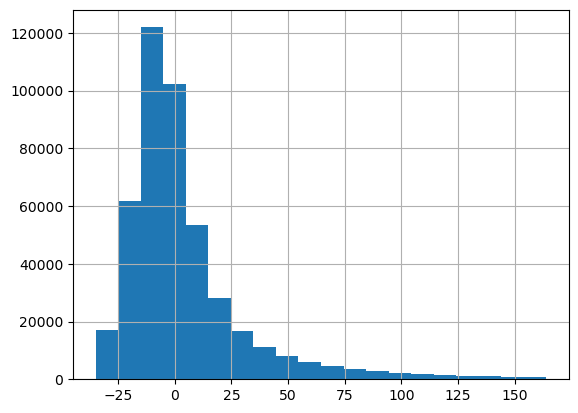

In [49]:
## without major outliers, still left skewed
## most flight arrive late rather than early
flights_m['ARRIVAL_DELAY'].hist(bins=20)

### final dataset

In [50]:
## targets
target_features = ['LATE_ARRIVAL']

In [51]:
### continuous features
model_features = ['SCHEDULED_TIME','DISTANCE',
                  'ARRIVAL_PROP','DEPARTURE_PROP',
                  'AIRLINE_ARRIVAL_PROP','AIRLINE_DEPARTURE_PROP',
                  'ARRIVAL_FLIGHT_COUNT','DEPARTURE_FLIGHT_COUNT',
                  'TOTAL_FLIGHTS_ARRIVAL_HOUR', 'TOTAL_FLIGHTS_DEPARTURE_HOUR']

In [52]:
## dimension features 
bool_prefixes = ('DEPART_', 'DEPARTURE_', 'ARRIVAL_', 'ARRIVE_', 'is_', 'AIRLINE_')
dim_features = [c for c in flights_m.columns if c.startswith(bool_prefixes) 
                and c not in['ARRIVAL_TIME','ARRIVAL_DELAY',
                             'ARRIVAL_HOUR','DEPARTURE_HOUR',
                             'DEPARTURE_TIME','DEPARTURE_DELAY','AIRLINE_NAME']]
dim_features = [c for c in dim_features if c not in model_features and c not in target_features]

In [53]:
flights_final = flights_m[model_features + dim_features + target_features]

print(flights_final.shape)
flights_final.head()

(447717, 698)


,SCHEDULED_TIME,DISTANCE,ARRIVAL_PROP,DEPARTURE_PROP,AIRLINE_ARRIVAL_PROP,AIRLINE_DEPARTURE_PROP,ARRIVAL_FLIGHT_COUNT,DEPARTURE_FLIGHT_COUNT,TOTAL_FLIGHTS_ARRIVAL_HOUR,TOTAL_FLIGHTS_DEPARTURE_HOUR,...,ARRIVE_TYS,ARRIVE_UST,ARRIVE_VEL,ARRIVE_VLD,ARRIVE_VPS,ARRIVE_WRG,ARRIVE_XNA,ARRIVE_YAK,ARRIVE_YUM,LATE_ARRIVAL
0,205.0,1448.0,0.854167,0.186704,0.121951,0.090909,41,132,48,707,...,0,0,0,0,0,0,0,0,0,0
1,280.0,2330.0,0.261402,0.185075,0.080851,0.209677,235,62,899,335,...,0,0,0,0,0,0,0,0,0,0
2,286.0,2296.0,0.356370,0.185075,0.084112,0.112903,428,62,1201,335,...,0,0,0,0,0,0,0,0,0,0
3,285.0,2342.0,0.261402,0.185075,0.080851,0.209677,235,62,899,335,...,0,0,0,0,0,0,0,0,0,0
4,235.0,1448.0,0.777778,0.185075,0.142857,0.080645,21,62,27,335,...,0,0,0,0,0,0,0,0,0,0


In [54]:
flights_final['LATE_ARRIVAL'].value_counts(dropna=False, normalize=True)

LATE_ARRIVAL
0    0.79598
1    0.20402
Name: proportion, dtype: float64

In [55]:
### save dataset
flights_final.to_csv('airline_dataset_normalized/flights_final_for_model.csv', index=None)